In [46]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [47]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

In [48]:
STUDENT_ID = "20212390077"
STUDENT_NAME = "周小梵"

In [49]:
DATA_DIR = r'D:\DataProject\Newyork Taxi'

In [50]:
plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False

In [51]:
def load_data(base_dir):
    """
    加载训练和测试数据集
    """
    train_path = os.path.join(base_dir, 'train.csv')
    test_path = os.path.join(base_dir, 'test.csv')

    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

    print("训练集基本信息:")
    print(train_df.info())

    print("\n测试集基本信息:")
    print(test_df.info())

    return train_df, test_df


In [52]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    计算两点间的哈弗辛距离
    """
    R = 6371  # 地球半径，单位千米

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [53]:
def advanced_feature_engineering(df):
    """
    高级特征工程
    """
    df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

    # 计算行程距离
    df['trip_distance'] = haversine_distance(
        df['pickup_latitude'], df['pickup_longitude'],
        df['dropoff_latitude'], df['dropoff_longitude']
    )

    # 时间特征
    df['hour'] = df['pickup_datetime'].dt.hour
    df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
    df['month'] = df['pickup_datetime'].dt.month
    df['day_of_month'] = df['pickup_datetime'].dt.day

    # 高峰期判断
    df['is_peak_hour'] = ((df['hour'] >= 7) & (df['hour'] <= 9) |
                          (df['hour'] >= 16) & (df['hour'] <= 18)).astype(int)

    return df

In [54]:
def data_visualization(df):
    """
    数据可视化函数
    """
    # 设置图形大小和布局
    plt.figure(figsize=(20, 15))

    # 1. 行程时间分布
    plt.subplot(2, 3, 1)
    sns.histplot(df['trip_duration'], kde=True)
    plt.title('行程时间分布')

    # 2. 行程距离分布
    plt.subplot(2, 3, 2)
    sns.histplot(df['trip_distance'], kde=True)
    plt.title('行程距离分布')

    # 3. 乘客数量分布
    plt.subplot(2, 3, 3)
    sns.countplot(x='passenger_count', data=df)
    plt.title('乘客数量分布')

    # 4. 上车时间小时分布
    plt.subplot(2, 3, 4)
    sns.countplot(x='hour', data=df)
    plt.title('上车时间小时分布')
    plt.xticks(rotation=45)

    # 5. 经纬度散点图
    plt.subplot(2, 3, 5)
    plt.scatter(df['pickup_longitude'], df['pickup_latitude'], alpha=0.1)
    plt.title('上车位置经纬度分布')

    # 6. 行程时间和距离关系
    plt.subplot(2, 3, 6)
    plt.scatter(df['trip_distance'], df['trip_duration'], alpha=0.1)
    plt.title('行程距离与时间关系')
    plt.xlabel('行程距离')
    plt.ylabel('行程时间')

    plt.tight_layout()
    plt.show()

In [55]:
def feature_correlation_analysis(df):
    """
    特征相关性分析
    """
    features = ['trip_duration', 'hour', 'day_of_week', 'month',
                'trip_distance', 'haversine_distance', 'passenger_count']

    correlation_matrix = df[features].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title('特征相关性矩阵')
    plt.tight_layout()
    plt.show()

In [56]:
def prepare_model_data(df):
    """
    准备模型训练数据
    """
    features = [
        'hour', 'day_of_week', 'month', 'day_of_month',
        'is_peak_hour', 'haversine_distance',
        'pickup_longitude', 'pickup_latitude',
        'dropoff_longitude', 'dropoff_latitude',
        'passenger_count', 'trip_distance'
    ]

    X = df[features]
    y = df['trip_duration']

    # 数据标准化
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, y, scaler

In [57]:
def train_and_evaluate_model(X, y):
    """
    模型训练与交叉验证
    """
    model = xgb.XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    )

    # 交叉验证
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_error')

    # 模型训练
    model.fit(X, y)

    # 打印评估结果
    print("交叉验证结果:")
    print(f"MAE: {-cv_scores.mean():.2f} (+/- {cv_scores.std() * 2:.2f})")

    return model

In [58]:
def save_model_with_scaler(model, scaler, base_dir):
    """
    保存模型和标准化器，文件名包含个人信息
    """
    model_filename = f"{STUDENT_ID}_{STUDENT_NAME}_taxi_model.joblib"
    scaler_filename = f"{STUDENT_ID}_{STUDENT_NAME}_taxi_scaler.joblib"

    model_path = os.path.join(base_dir, model_filename)
    scaler_path = os.path.join(base_dir, scaler_filename)

    joblib.dump(model, model_path)
    joblib.dump(scaler, scaler_path)

    print(f"模型已保存: {model_path}")
    print(f"标准化器已保存: {scaler_path}")

In [59]:
def main():
    # 加载数据
    train_df, test_df = load_data(DATA_DIR)

    # 数据可视化
    data_visualization(train_df)

    # 特征工程
    train_df = advanced_feature_engineering(train_df)

    # 特征相关性分析
    feature_correlation_analysis(train_df)

    # 准备模型数据
    X, y, scaler = prepare_model_data(train_df)

    # 训练模型
    model = train_and_evaluate_model(X, y)

    # 保存模型
    save_model_with_scaler(model, scaler, DATA_DIR)


训练集基本信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB
None

测试集基本信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625134 entries, 0 to 625133
Data columns (total 9 columns):
 #   Column              N

D:\data\conda\envs\ML\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
D:\data\conda\envs\ML\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


KeyError: 'trip_distance'

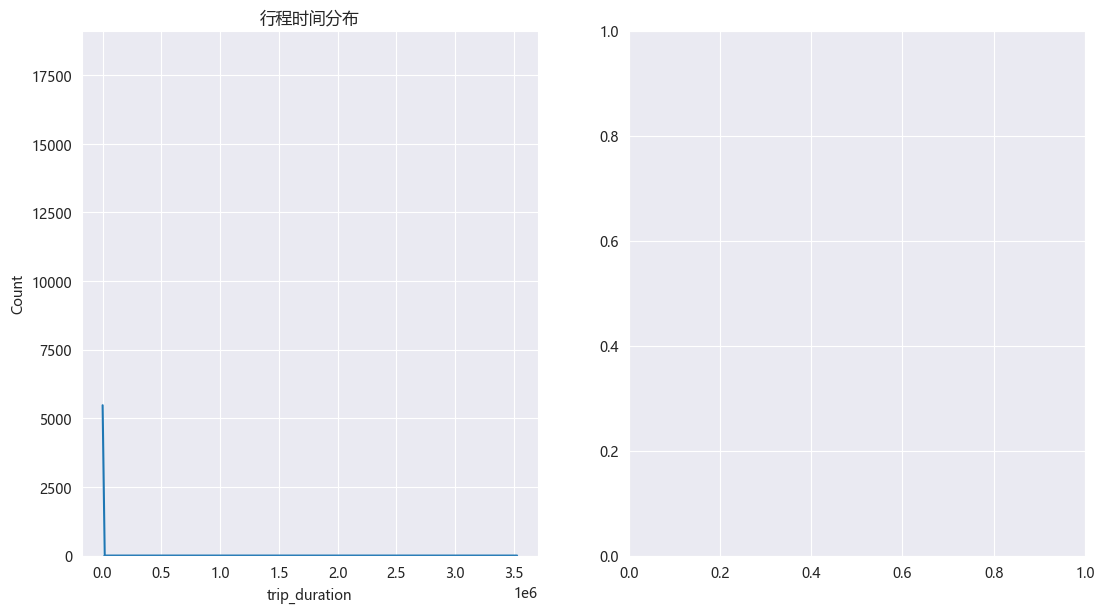

In [60]:
if __name__ == '__main__':
    main()